# YUVAA Internship — Week 4
## Scenario Analysis and Risk Assessment in Agribusiness

**Prepared by:** Avirup Karmakar

This notebook uses the historical crop-production data and the Week 3 baseline trend approach to create transparent production scenarios, assess risks, and propose mitigation strategies.


## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load Dataset

In [2]:
df = pd.read_csv("crop_production.csv")

df.columns = [c.strip() for c in df.columns]
for c in ["State_Name", "District_Name", "Season", "Crop"]:
    if c in df.columns:
        df[c] = df[c].astype("string").str.strip()

for c in ["Crop_Year", "Area", "Production"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.drop_duplicates()
analysis_df = df.dropna(
    subset=["Crop_Year", "Area", "Production"]
).copy()

analysis_df = analysis_df[
    (analysis_df["Area"] >= 0) &
    (analysis_df["Production"] >= 0)
].copy()

print("Rows used for Week 4 analysis:", len(analysis_df))
display(analysis_df.head())


Rows used for Week 4 analysis: 65285


,index,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,0,Andaman and Nicobar Islands,NICOBARS,2000.0,Kharif,Arecanut,1254.0,2000.0
1,1,Andaman and Nicobar Islands,NICOBARS,2000.0,Kharif,Other Kharif pulses,2.0,1.0
2,2,Andaman and Nicobar Islands,NICOBARS,2000.0,Kharif,Rice,102.0,321.0
3,3,Andaman and Nicobar Islands,NICOBARS,2000.0,Whole Year,Banana,176.0,641.0
4,4,Andaman and Nicobar Islands,NICOBARS,2000.0,Whole Year,Cashewnut,720.0,165.0


## 3. Historical Annual Production

In [3]:
annual = (
    analysis_df.groupby("Crop_Year")["Production"]
    .sum()
    .reset_index()
    .sort_values("Crop_Year")
)

annual["YoY_Growth_%"] = annual["Production"].pct_change() * 100
display(annual)


,Crop_Year,Production,YoY_Growth_%
0,1997.0,7.450872e+07,NaN
1,1998.0,2.375072e+08,218.764271
2,1999.0,2.240536e+08,-5.664500
3,2000.0,1.386455e+09,518.804913
4,2001.0,1.455394e+09,4.972356
5,2002.0,1.481109e+09,1.766901
6,2003.0,1.528300e+09,3.186191
7,2004.0,1.691206e+09,10.659249
8,2005.0,1.187231e+09,-29.799734
9,2006.0,1.763615e+09,48.548642


In [4]:
mean_prod = annual["Production"].mean()
std_prod = annual["Production"].std()
cv = std_prod / mean_prod * 100

print("Mean annual production:", mean_prod)
print("Standard deviation:", std_prod)
print("Coefficient of variation (%):", cv)


Mean annual production: 1204420629.6855555
Standard deviation: 643155432.6762545
Coefficient of variation (%): 53.3995696208032


## 4. Identify Historical Extremes

In [5]:
valid_growth = annual.dropna(subset=["YoY_Growth_%"])

print("Largest year-over-year increase:")
display(valid_growth.loc[valid_growth["YoY_Growth_%"].idxmax()])

print("Largest year-over-year decline:")
display(valid_growth.loc[valid_growth["YoY_Growth_%"].idxmin()])


Largest year-over-year increase:


,3
Crop_Year,2.000000e+03
Production,1.386455e+09
YoY_Growth_%,5.188049e+02


Largest year-over-year decline:


,10
Crop_Year,2.007000e+03
Production,3.846209e+08
YoY_Growth_%,-7.819134e+01


## 5. Baseline Trend Model

In [6]:
X_year = annual[["Crop_Year"]]
y_prod = annual["Production"]

trend_model = LinearRegression()
trend_model.fit(X_year, y_prod)

annual["Trend_Fitted"] = trend_model.predict(X_year)

last_year = int(annual["Crop_Year"].max())
baseline_next = float(
    trend_model.predict([[last_year + 1]])[0]
)

print("Last observed year:", last_year)
print("Baseline next-year estimate:", baseline_next)


Last observed year: 2014
Baseline next-year estimate: 1842228968.0955658


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## 6. Scenario Development

In [7]:
# Transparent sensitivity assumptions
scenarios = pd.DataFrame({
    "Scenario": [
        "Favorable Growth",
        "Baseline Trend",
        "Moderate Disruption",
        "Severe Disruption"
    ],
    "Change_vs_Baseline_%": [10, 0, -10, -20]
})

scenarios["Projected_Production"] = (
    baseline_next *
    (1 + scenarios["Change_vs_Baseline_%"] / 100)
)

scenarios["Difference_vs_Baseline"] = (
    scenarios["Projected_Production"] - baseline_next
)

display(scenarios)


,Scenario,Change_vs_Baseline_%,Projected_Production,Difference_vs_Baseline
0,Favorable Growth,10,2.026452e+09,1.842229e+08
1,Baseline Trend,0,1.842229e+09,0.000000e+00
2,Moderate Disruption,-10,1.658006e+09,-1.842229e+08
3,Severe Disruption,-20,1.473783e+09,-3.684458e+08


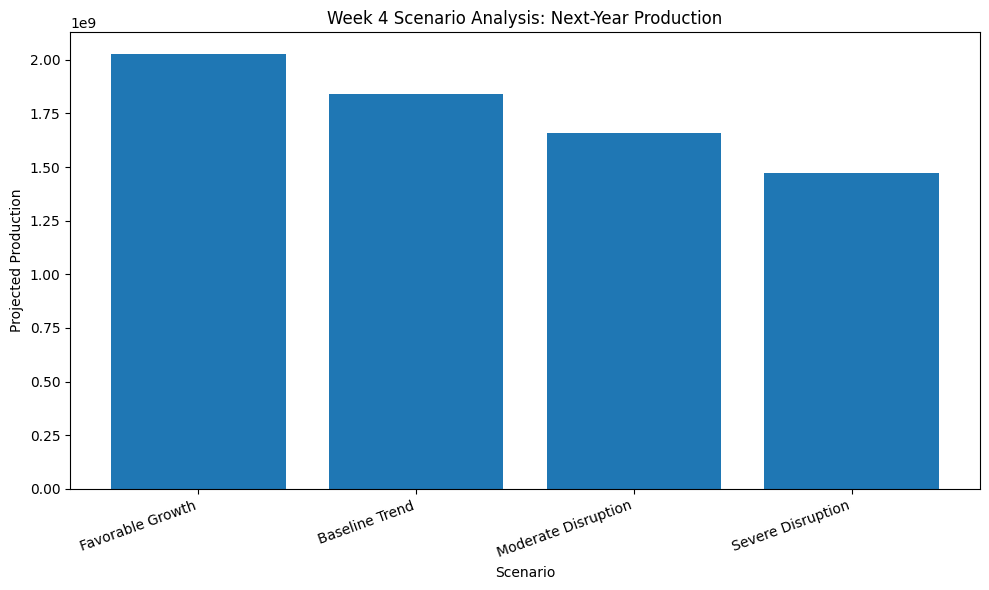

In [8]:
plt.figure(figsize=(10, 6))

plt.bar(
    scenarios["Scenario"],
    scenarios["Projected_Production"]
)

plt.title("Week 4 Scenario Analysis: Next-Year Production")
plt.xlabel("Scenario")
plt.ylabel("Projected Production")
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()


### Scenario interpretation

The four cases are sensitivity scenarios, not probability estimates. They show how operational planning changes when production is above or below the baseline by a defined percentage.


## 7. Risk Register

In [9]:
risk_register = pd.DataFrame({
    "Risk": [
        "Production volatility",
        "Area-production variability",
        "Seasonal concentration",
        "Regional concentration",
        "Forecast model uncertainty"
    ],
    "Likelihood": ["High", "Medium", "High", "Medium", "Medium"],
    "Impact": ["High", "High", "Medium", "High", "Medium"]
})

display(risk_register)


,Risk,Likelihood,Impact
0,Production volatility,High,High
1,Area-production variability,Medium,High
2,Seasonal concentration,High,Medium
3,Regional concentration,Medium,High
4,Forecast model uncertainty,Medium,Medium


### Risk interpretation

Likelihood and impact ratings here are qualitative planning labels based on the dataset behavior and modelling limitations. They are not formal statistical probabilities.


## 8. Risk Mitigation Strategies


- **Production volatility:** Use rolling monitoring, scenario-based procurement and inventory trigger levels.
- **Regional concentration:** Diversify sourcing across alternate states/regions and supplier networks.
- **Seasonal concentration:** Align storage, transport and processing capacity with seasonal peaks.
- **Forecast uncertainty:** Add weather, prices, irrigation, inputs and other external predictors in later models.
- **Area-production variability:** Monitor cultivated area and production together and investigate sharp deviations.


## 9. Historical + Baseline Visualization

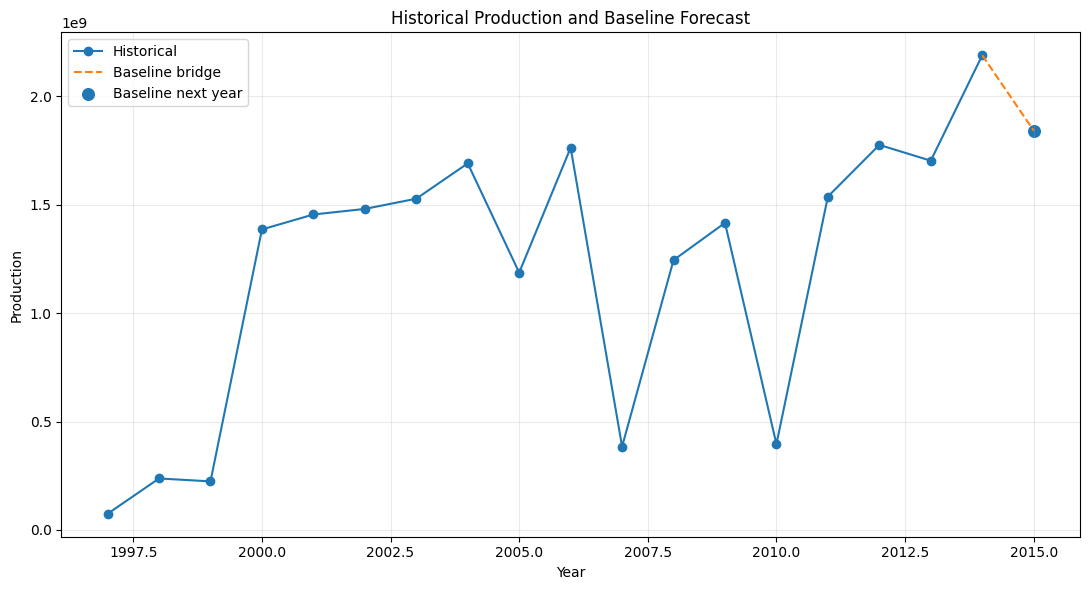

In [10]:
plt.figure(figsize=(11, 6))

plt.plot(
    annual["Crop_Year"],
    annual["Production"],
    marker="o",
    label="Historical"
)

plt.plot(
    [last_year, last_year + 1],
    [
        annual.loc[annual["Crop_Year"] == last_year, "Production"].iloc[0],
        baseline_next
    ],
    linestyle="--",
    label="Baseline bridge"
)

plt.scatter(
    [last_year + 1],
    [baseline_next],
    s=70,
    label="Baseline next year"
)

plt.title("Historical Production and Baseline Forecast")
plt.xlabel("Year")
plt.ylabel("Production")
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()


## 10. Conclusion

Week 4 uses scenario sensitivity and qualitative risk assessment to convert the earlier analytical work into an operational planning framework. The percentage scenarios should be updated as new evidence becomes available.
